In [1]:
from pathlib import Path

DATA_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/processed")
image_paths = sorted(DATA_DIR.glob("*.png"))
labels = [ord(image_path.name[0].lower()) - ord("a") for image_path in image_paths]

print(labels)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,

In [4]:
from pathlib import Path

from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

DATA_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/processed").with_suffix('')
image_count = len(list(DATA_DIR.glob('*.png')))
print(image_count)

781


Found 781 files belonging to 26 classes.
Using 625 files for training.
Using 156 files for validation.
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]], shape=(256, 256, 1), dtype=float32)
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]], shape=(256, 256, 1), dtype=float32)
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
 

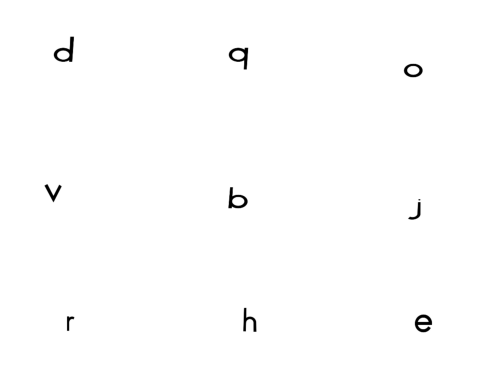

2026-09-16 12:55:04.163660: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels=labels,
    validation_split=0.2,
    subset="both",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
)

# val_ds = tf.keras.utils.image_dataset_from_directory(
#     DATA_DIR,
#     labels=labels,
#     validation_split=0.2,
#     subset="validation",
#     seed=SEED,
#     image_size=IMG_SIZE,
#     color_mode="grayscale",
#     batch_size=BATCH_SIZE,
# )

class_names = train_ds.class_names
num_classes = len(class_names)

image_batch, label_batch = next(iter(train_ds))

import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # 1. Grab the image tensor and drop the trailing channel dimension
        # This changes the shape from (30, 30, 1) to (30, 30)
        print(images[i])
        img = np.squeeze(images[i].numpy())
        
        # 2. Force Matplotlib to render it as grayscale using cmap='gray'
        # Also cast to uint8 to keep values correctly ranged 0-255
        plt.imshow(img, cmap="gray")
        
        plt.axis("off")
    plt.show()


Epoch 1/100


2026-09-16 13:02:44.902918: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.0592 - loss: 5.8735 - val_accuracy: 0.0513 - val_loss: 3.2728 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.0544 - loss: 3.5933 - val_accuracy: 0.0385 - val_loss: 3.2733 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.0832 - loss: 3.1636 - val_accuracy: 0.0321 - val_loss: 3.3147 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.1168 - loss: 2.9683 - val_accuracy: 0.0385 - val_loss: 3.3421 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.1536 - loss: 2.7987 - val_accuracy: 0.0321 - val_loss: 3.3627 - learning_rate: 5.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.2336 - loss: 2.5099 - val_accuracy: 0.0321 - val_loss: 3.3719 - learning_rate: 5.0000e-04
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.2960 - loss: 2.5117

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 26)             │       193,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,354 (755.29 KB)

 Trainable params: 192,874 (753.41 KB)

 Non-trainable params: 480 (1.88 KB)

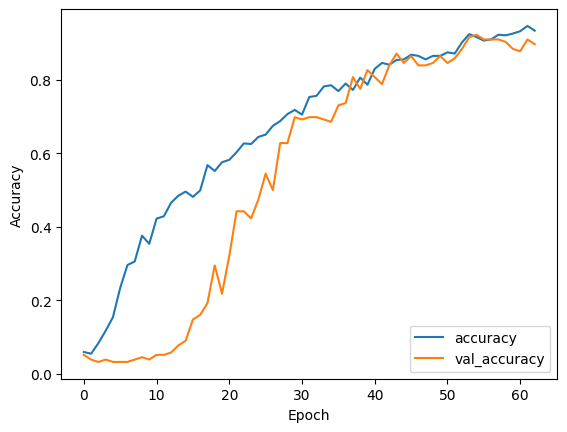

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

model_core = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(16, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalMaxPooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

model_train = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),
    data_augmentation,
    model_core,
])

model_train.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        start_from_epoch=50
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    ),
]

history = model_train.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

print("Classes:", class_names)
model_train.summary()
model_core.summary()

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

[[2.75297934e-05 4.27901296e-06 1.27992344e-05 5.13687010e-05
  1.16762309e-03 2.49752998e-01 4.82523092e-06 3.64788622e-02
  6.05464047e-05 2.38026345e-07 8.88723123e-04 3.47366631e-01
  3.02787335e-03 3.48933460e-03 1.18303475e-07 1.89491583e-03
  6.06708491e-05 6.66185841e-02 3.41408188e-03 1.53583577e-02
  1.56605847e-06 2.59042829e-01 7.79645634e-04 7.45381881e-03
  2.23296720e-05 3.01952101e-03]]


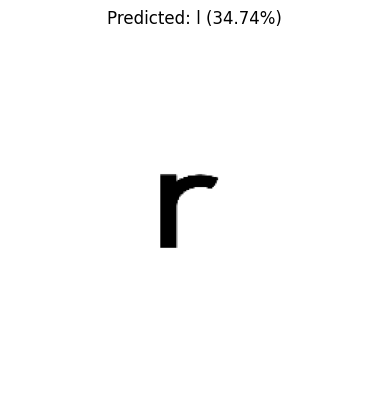

File: r.png
Predicted class: l
Confidence: 34.74%


In [105]:
import random

image_path = random.choice(list(DATA_DIR.glob("*.png")))

image = tf.keras.utils.load_img(
    image_path,
    color_mode="grayscale",
    target_size=IMG_SIZE,
)
image_array = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_array, axis=0)

predictions = model_core.predict(image_batch, verbose=0)
print(predictions)
predicted_index = int(np.argmax(predictions[0]))
alphabet = ["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v","w","x","y","z"]

predicted_class = alphabet[predicted_index]
confidence = float(predictions[0][predicted_index])

plt.imshow(np.squeeze(image_array), cmap="gray")
plt.axis("off")
plt.title(f"Predicted: {predicted_class} ({confidence:.2%})")
plt.show()

print(f"File: {image_path.name}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2%}")

In [106]:
model_core.save('luisterschelp4.keras')
converter = tf.lite.TFLiteConverter.from_keras_model(model_core)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS] # Pure native ops

tflite_model = converter.convert()
with open("model4.tflite", "wb") as f:
    f.write(tflite_model)
print("Success! Converted cleanly without Flex Ops.")

INFO:tensorflow:Assets written to: /var/folders/fd/lhs046h96bn67ks1050l62qm0000gn/T/tmplghnxa3b/assets


INFO:tensorflow:Assets written to: /var/folders/fd/lhs046h96bn67ks1050l62qm0000gn/T/tmplghnxa3b/assets


: 

In [4]:
import tensorflow as tf
from pathlib import Path

tf.keras.backend.clear_session()

trained_model = tf.keras.models.load_model(
    "luisterschelp.keras",
    compile=False,
)

# Identify the nested augmentation Sequential layer.
augmentation_layer = next(
    layer
    for layer in trained_model.layers
    if isinstance(layer, tf.keras.Sequential)
    and any(
        layer_name.startswith(("random_rotation", "random_zoom"))
        for layer_name in [child.name for child in layer.layers]
    )
)

# Reuse the trained layers, excluding augmentation.
inference_layers = [
    layer for layer in trained_model.layers
    if layer is not augmentation_layer
]

inference_model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(256, 256, 1)),
        *inference_layers,
    ]
)

saved_model_dir = Path("luisterschelp_saved_model")
inference_model.export(
        saved_model_dir,
        input_signature=[
            tf.TensorSpec([1, 256, 256, 1], tf.float32),
        ],
    )

converter = tf.lite.TFLiteConverter.from_saved_model(
    str(saved_model_dir)
)
tflite_model = converter.convert()

with tf.io.gfile.GFile("model.tflite", "wb") as file:
    file.write(tflite_model)

print("Created model.tflite")

INFO:tensorflow:Assets written to: luisterschelp_saved_model/assets


INFO:tensorflow:Assets written to: luisterschelp_saved_model/assets


Saved artifact at 'luisterschelp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 256, 256, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 26), dtype=tf.float32, name=None)
Captures:
  5675668352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704441120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704439184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704437600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704446224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704447808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704438480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704663632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704669792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704671552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5704669968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  57046

W0000 00:00:1789231577.212801 5951894 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1789231577.212822 5951894 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-09-12 18:46:17.212980: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: luisterschelp_saved_model
2026-09-12 18:46:17.213384: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-09-12 18:46:17.213387: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: luisterschelp_saved_model
2026-09-12 18:46:17.219644: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-09-12 18:46:17.241698: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: luisterschelp_saved_model
2026-09-12 18:46:17.247912: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 34932 microseconds.
2026-09-12 18:46:1

In [7]:
import random

image_path = random.choice(list(DATA_DIR.glob("*.png")))

image = tf.keras.utils.load_img(
    image_path,
    color_mode="grayscale",
    target_size=IMG_SIZE,
)
image_array = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_array, axis=0)

predictions = model.predict(image_batch, verbose=0)
print(predictions)
predicted_index = int(np.argmax(predictions[0]))
alphabet = ["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v","w","x","y","z"]

predicted_class = alphabet[predicted_index]
confidence = float(predictions[0][predicted_index])

plt.imshow(np.squeeze(image_array), cmap="gray")
plt.axis("off")
plt.title(f"Predicted: {predicted_class} ({confidence:.2%})")
plt.show()

print(f"File: {image_path.name}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2%}")

NameError: name 'model' is not defined

INFO:tensorflow:Assets written to: /Users/koensauren/Documents/luisterschelp/model_trainer/luisterschelp3_saved_model/assets


INFO:tensorflow:Assets written to: /Users/koensauren/Documents/luisterschelp/model_trainer/luisterschelp3_saved_model/assets


Saved artifact at '/Users/koensauren/Documents/luisterschelp/model_trainer/luisterschelp3_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  5701466096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5699111920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5699123184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5695537392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5699118608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5699120896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5695551824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5695543552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5695964784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5695963904: TensorSpec(shape=(), dtype=tf.resource, name=None

W0000 00:00:1789556322.539407  460029 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1789556322.539417  460029 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-09-16 12:58:42.539507: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /Users/koensauren/Documents/luisterschelp/model_trainer/luisterschelp3_saved_model
2026-09-16 12:58:42.539870: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-09-16 12:58:42.539873: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /Users/koensauren/Documents/luisterschelp/model_trainer/luisterschelp3_saved_model
2026-09-16 12:58:42.544863: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-09-16 12:58:42.564363: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: /Users/koensauren/Documents/luisterschelp/model_trainer/luisterschelp3_saved_model


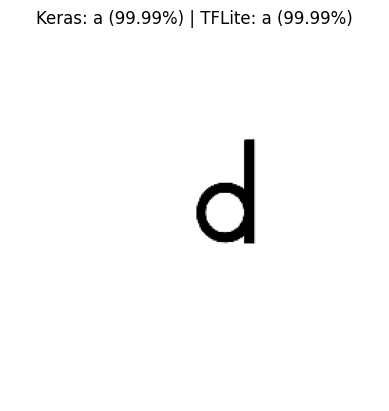

File: d_left.png
Keras prediction: a
Keras confidence: 99.99%
TFLite prediction: a
TFLite confidence: 99.99%
Expected class: d
Maximum output difference: 4.1473e-10


In [24]:
keras_model = tf.keras.models.load_model(
    KERAS_MODEL_PATH,
    compile=False,
)

saved_model_dir = MODEL_DIR / "luisterschelp3_saved_model"
if tf.io.gfile.exists(str(saved_model_dir)):
    tf.io.gfile.rmtree(str(saved_model_dir))

keras_model.export(saved_model_dir)

converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
converter.experimental_enable_resource_variables = False
tflite_model = converter.convert()

with tf.io.gfile.GFile(str(TFLITE_MODEL_PATH), "wb") as file:
    file.write(tflite_model)

interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("TensorFlow:", tf.__version__)
print("Keras model:", KERAS_MODEL_PATH.resolve())
print("TFLite model:", TFLITE_MODEL_PATH.resolve())
print("TFLite input:", input_details)
print("TFLite output:", output_details)

image_path = random.choice(list(DATA_DIR.glob("*.png")))
image = tf.keras.utils.load_img(
    image_path,
    color_mode="grayscale",
    target_size=IMAGE_SIZE,
)
image_array = tf.keras.utils.img_to_array(image)
image_batch = np.expand_dims(image_array, axis=0).astype(np.float32)

keras_output = keras_model(image_batch, training=False).numpy()

input_data = image_batch.astype(input_details["dtype"])
interpreter.set_tensor(input_details["index"], input_data)
interpreter.invoke()

tflite_output = interpreter.get_tensor(output_details["index"])[0]

keras_index = int(np.argmax(keras_output[0]))
tflite_index = int(np.argmax(tflite_output))
expected_class = image_path.stem[0].lower()

plt.imshow(np.squeeze(image_array), cmap="gray")
plt.axis("off")
plt.title(
    f"Keras: {ALPHABET[keras_index]} ({keras_output[0][keras_index]:.2%}) | "
    f"TFLite: {ALPHABET[tflite_index]} ({tflite_output[tflite_index]:.2%})"
)
plt.show()

print(f"File: {image_path.name}")
print(f"Keras prediction: {ALPHABET[keras_index]}")
print(f"Keras confidence: {keras_output[0][keras_index]:.2%}")
print(f"TFLite prediction: {ALPHABET[tflite_index]}")
print(f"TFLite confidence: {tflite_output[tflite_index]:.2%}")
print(f"Expected class: {expected_class}")
print(f"Maximum output difference: {np.max(np.abs(keras_output - tflite_output)):.6g}")